In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm

In [2]:
plt.rcParams['figure.figsize'] = (10,8)
plt.rcParams['figure.dpi'] = 100 
plt.rcParams['font.size'] = 14 

In [17]:
df = pd.read_excel('data/Sales.xlsx')

In [4]:
df

,Week,Sales_Volume,Price,Ads_Cost
0,1,350,5.5,3.3
1,2,460,7.5,3.3
2,3,350,8.0,3.0
3,4,430,8.0,4.5
4,5,350,6.8,3.0
5,6,380,7.5,4.0
6,7,430,4.5,3.0
7,8,480,6.5,3.8
8,9,450,7.0,3.5
9,10,490,5.0,4.0


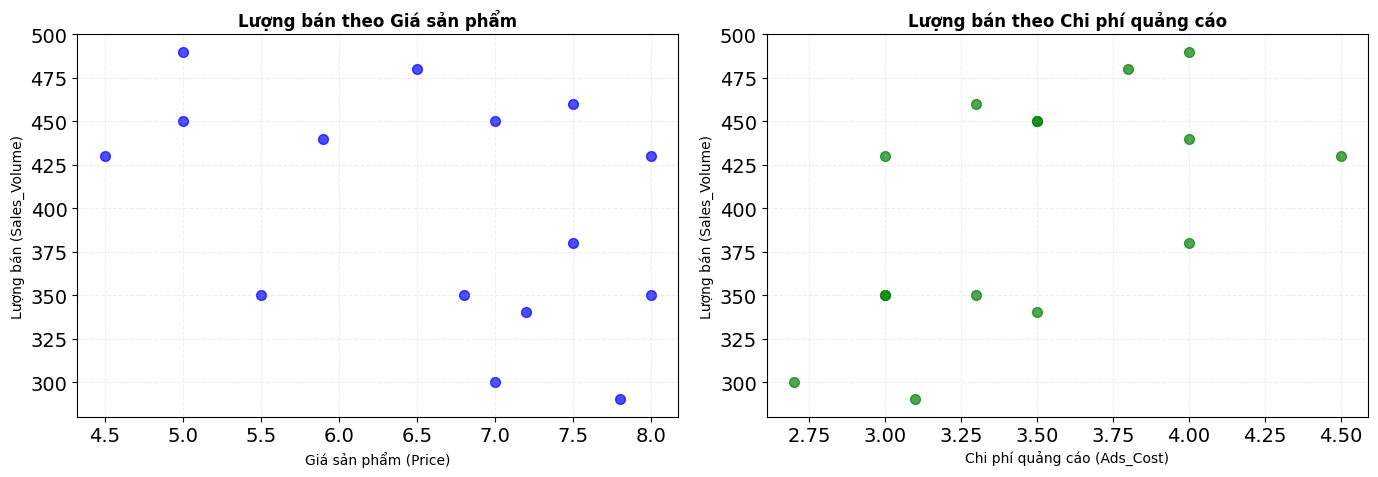

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Biểu đồ lượng bán theo giá sản phẩm
ax1.scatter(df['Price'], df['Sales_Volume'], color='blue', s=50, alpha=0.7)
ax1.set_title('Lượng bán theo Giá sản phẩm', fontsize=12, fontweight='bold')
ax1.set_xlabel('Giá sản phẩm (Price)', fontsize=10)
ax1.set_ylabel('Lượng bán (Sales_Volume)', fontsize=10)
ax1.grid(True, linestyle='--', alpha=0.2)

# Biểu đồ lượng bán theo chi phí quảng cáo
ax2.scatter(df['Ads_Cost'], df['Sales_Volume'], color='green', s=50, alpha=0.7)
ax2.set_title('Lượng bán theo Chi phí quảng cáo', fontsize=12, fontweight='bold')
ax2.set_xlabel('Chi phí quảng cáo (Ads_Cost)', fontsize=10)
ax2.set_ylabel('Lượng bán (Sales_Volume)', fontsize=10)
ax2.grid(True, linestyle='--', alpha=0.2)

plt.tight_layout()
plt.show()

## Nhận xét : 
- Với lượng bán theo giá sản phẩm ta thấy được một chút xu hướng giảm lượng bán khi giá của sản phẩm tăng, vẫn xuất hiện sản phẩm có giá bán cao và số lượng cũng cao (thực tế vẫn có, tùy vào tính chất của sản phảm). 
- Với lượng bán theo chi phí quảng cáo thì thấy được rõ hơn về xu hướng tăng khi chi phí quảng cáo tăng.

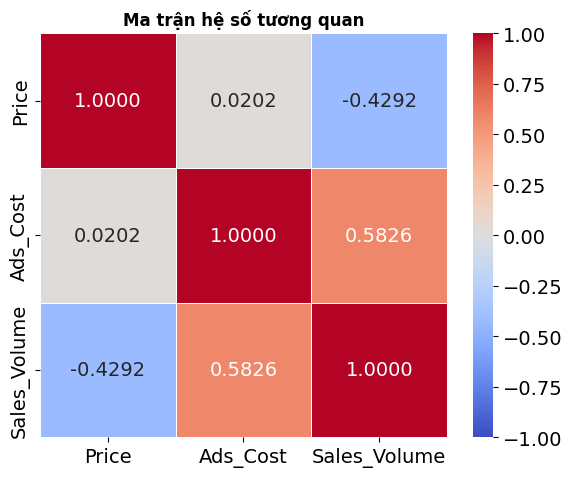

In [6]:
corr_matrix = df[['Price', 'Ads_Cost', 'Sales_Volume']].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".4f", linewidths=.5, vmin=-1, vmax=1)
plt.title('Ma trận hệ số tương quan', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()



In [7]:
x = df[['Price', 'Ads_Cost']]
y = df['Sales_Volume']
x,y = np.array(x), np.array(y)
x = sm.add_constant(x)

In [8]:
model = sm.OLS(y, x)
results = model.fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.534
Model:                            OLS   Adj. R-squared:                  0.456
Method:                 Least Squares   F-statistic:                     6.874
Date:                Sat, 23 May 2026   Prob (F-statistic):             0.0102
Time:                        12:49:46   Log-Likelihood:                -77.775
No. Observations:                  15   AIC:                             161.5
Df Residuals:                      12   BIC:                             163.7
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        292.5701    115.939      2.523      0.0

## Lượng bán = 292.5701 - 24.8527 * giá + 77.9087 * Quảng cáo  ( y = a + x1.b+ x2.b2  )  
 (Khi các yếu tố khác không đổi) : 
- 292.5701 gọi là hệ số chặn, là điểm mà đường hồi quy cắt trục y khi tất cả các biến bằng không. Có nghĩa là nếu giá trị của giá và chi phí quảng cáo không tác động (không đổi) thì giá trị dự đoán sẽ là 292.5701
- -24.8527 , có nghĩa là nếu ta tăng giá một đơn vị thì số lượng bán giảm 24.85 đơn vị.
- 77.9087 , có nghĩa là nếu ta tăng chi phí quảng cáo 1 đơn vị, lượng bán tăng  77.91 đơn vị.

In [9]:
f_pvalue = results.f_pvalue
print(f_pvalue)

0.010245810401190592


- Ho : giá và chi phí quảng cáo không tác động đến lượng bán
- h1 : giá và chi phí quảng cáo có tác động đến lượng bán
- ta nhận được p-value = 0.010 -> Với mức ý nghĩa 5% ta bác bỏ H0 và chấp nhận H1 rằng giá và chi phí quảng cáo có tác động đến lượng bán

In [10]:
data_pred = pd.DataFrame(
    {
        'Price': [ 4.3, 4.9],
        'Ads_Cost': [4.1 ,4.4]
    }
)

predicted_sales = results.predict(sm.add_constant(data_pred))
print(predicted_sales)

0    505.129305
1    513.590309
dtype: float64


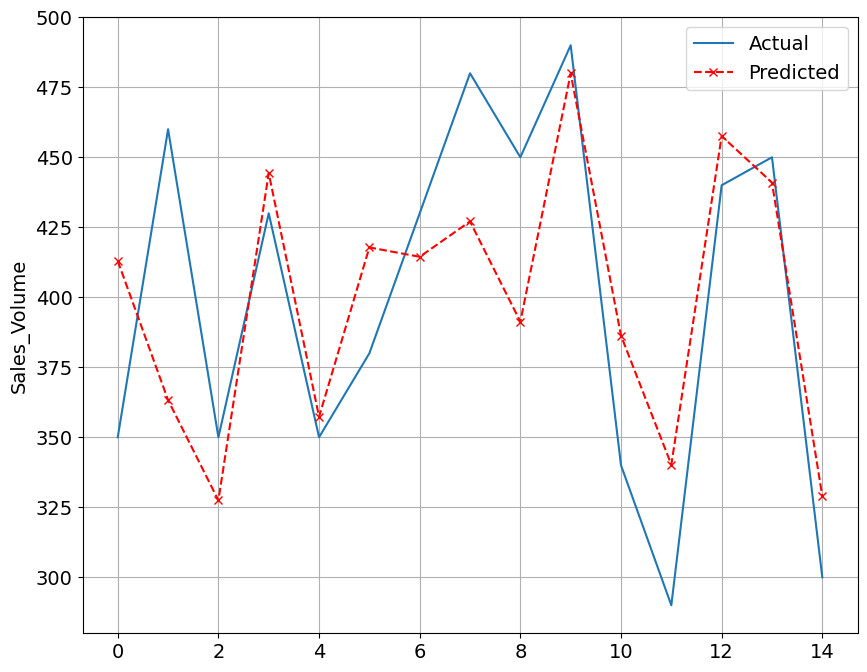

In [11]:
predicted_values = results.predict(x)
plt.plot(df["Sales_Volume"], label="Actual")
plt.plot(predicted_values, label="Predicted",color='red',marker='x',linestyle='--')
plt.ylabel("Sales_Volume")
plt.legend()
plt.grid(True)
plt.show()